# PCAD Results Analysis

Unified analysis of PCAD (Performance Characterization and Analysis for DNN) large-scale training results.

## Configuration

In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path


def find_project_root(start: Path | None = None):
    """Walk upward until the repository root is found."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "results").exists() and (candidate / "models").exists():
            return candidate
    return start


project_root = find_project_root()
print(f"Project root: {project_root}")

PCAD_DIR = project_root / "outputs" / "pcad"
LARGE_SCALE_DIR = PCAD_DIR / "archive_legacy_phases" / "phase_4_5_large_scale"

# Figures output
FIGURES_DIR = PCAD_DIR / "figures_generated"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PCAD directory: {PCAD_DIR}")
print(f"Output figures to: {FIGURES_DIR}")

Project root: /home/users/rsdsouza/dnn_study
PCAD directory: /home/users/rsdsouza/dnn_study/outputs/pcad
Output figures to: /home/users/rsdsouza/dnn_study/outputs/pcad/figures_generated


## Load Data

In [16]:
def load_pcad_comparison():
    """Load results_phase_4_5_large_scale.csv from PCAD results."""
    csv_path = PCAD_DIR / "results_aggregate" / "results_phase_4_5_large_scale.csv"
    if not csv_path.exists():
        print(f"[skip] No results_phase_4_5_large_scale.csv found")
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    return df


def load_model_summaries():
    """Load all *_summary.json files from PCAD (any subdirectory)."""
    rows = []
    if not PCAD_DIR.exists():
        print(f"[skip] {PCAD_DIR} not found")
        return pd.DataFrame()

    # Search all subdirectories recursively for *_summary.json
    for model_dir in sorted(PCAD_DIR.rglob("*_summary.json")):
        try:
            with open(model_dir) as fp:
                data = json.load(fp)
            rows.append(data)
        except Exception as e:
            print(f"[skip] {model_dir}: {e}")

    df = pd.DataFrame(rows) if rows else pd.DataFrame()
    if not df.empty and "model_name" in df.columns and "epochs" in df.columns:
        # Ablation models (e.g. alexnet_fire_bypass) can have multiple summary.json files —
        # an early-stopped ablation run plus a later full-budget rerun. Keep the most-trained
        # (highest-epoch) one per model_name so charts don't get duplicate/conflicting rows.
        df = df.sort_values("epochs").drop_duplicates(subset="model_name", keep="last").reset_index(drop=True)
    return df


df_comp = load_pcad_comparison()
df_summ = load_model_summaries()

print(f"Comparison rows : {len(df_comp):3d}")
print(f"Per-model JSONs : {len(df_summ):3d}")
print(f"\nComparison columns: {list(df_comp.columns[:10])}..." if len(df_comp.columns) > 10 else f"\nComparison columns: {list(df_comp.columns)}")

Comparison rows :   1
Per-model JSONs :  15

Comparison columns: ['model_name', 'mode', 'epochs', 'best_val_top1', 'best_val_top5', 'final_val_top1', 'final_val_top5', 'best_val_loss', 'final_train_loss', 'fp32_top1']...


## All-Model Summary Table

In [17]:
if not df_summ.empty:
    # Display key columns from model summaries
    key_cols = [c for c in ['model_name', 'fp32_top1', 'int8_top1', 'quantization_drop_top1', 
                             'fp32_size_mb', 'int8_size_mb', 'params_m', 'macs'] if c in df_summ.columns]
    display(df_summ[key_cols].sort_values('fp32_top1', ascending=False).reset_index(drop=True))
    print(f"\n→ Loaded {len(df_summ)} models from summary JSONs")
elif not df_comp.empty:
    key_cols = [c for c in ['model_name', 'fp32_top1', 'int8_top1', 'quantization_drop_top1', 
                             'fp32_size_mb', 'int8_size_mb', 'params_m', 'macs'] if c in df_comp.columns]
    display(df_comp[key_cols].sort_values('fp32_top1', ascending=False).reset_index(drop=True))
else:
    print("[skip] No data loaded")

,model_name,fp32_top1,int8_top1,quantization_drop_top1,fp32_size_mb,int8_size_mb,params_m,macs
0,mobilenetv2,56.548774,51.940668,4.608107,28.753939,3.043859,2.480072,25799936
1,resnet18tv,51.525134,55.577213,-4.052079,129.209360,10.969807,11.279112,148555776
2,alexnet_final_fire_residual,51.217693,50.040364,1.177329,8.094206,0.747059,0.698664,55236608
3,alexnet_fire,50.588840,50.552118,0.036722,5.989412,0.553228,0.516152,177670144
4,vgg_style,50.366628,52.506649,-2.140021,27.584873,2.377123,2.405288,231086080
5,alexnet_final_bottleneck_fire,49.205637,49.782503,-0.576866,5.882293,0.546124,0.506408,47282176
6,alexnet_fire_bypass,49.026531,49.864638,-0.838107,5.990506,0.554306,0.516152,177670144
7,alexnet_final_bottleneck_residual,48.909345,49.518880,-0.609535,6.653960,0.635242,0.571304,54175744
8,alexnet_bottleneck,48.465678,49.188003,-0.722325,4.491745,0.432230,0.385000,39512064
9,alexnet_smallkernel,47.771913,23.613423,24.158490,18.353327,1.561806,1.602376,460179456



→ Loaded 15 models from summary JSONs


In [18]:
# Consolidate: use df_summ (all 14 models) for visualizations, fallback to df_comp for compatibility
df_data = df_summ if not df_summ.empty else df_comp
print(f"Using {len(df_data)} models for visualizations")

Using 15 models for visualizations


## Setup Visualization Defaults

In [19]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11})

# Color palette (quantization stage — used where FP32 vs INT8 is the primary label)
COLORS = {
    'fp32': '#1f77b4',
    'int8': '#ff7f0e',
    'baseline': '#2ca02c',
    'efficient': '#d62728'
}

# Model family palette (used wherever color isn't already spoken for by fp32/int8) —
# fixed hue order, not cycled, so a family keeps its color across every chart.
BASELINE_MODELS = {"alexnet_tv", "vgg_style", "resnet18tv", "mobilenetv2"}
KERNEL_RESTRICTION_PREFIXES = ("alexnet_3x3", "alexnet_2x2", "alexnet_smallkernel", "alexnet_stacked", "alexnet_mixed")


def model_category(name: str) -> str:
    """Phase family a model belongs to, per the Model Inventory in CLAUDE.md."""
    if name in BASELINE_MODELS:
        return "baseline"
    if name.startswith("alexnet_final"):
        return "final_architecture"
    if "bypass" in name:
        return "ablation"
    if name.startswith(KERNEL_RESTRICTION_PREFIXES):
        return "kernel_restriction"
    return "compensation"


CATEGORY_ORDER = ["baseline", "kernel_restriction", "compensation", "final_architecture", "ablation"]
CATEGORY_COLORS = {
    "baseline": "#2a78d6",             # blue
    "kernel_restriction": "#eb6834",   # orange
    "compensation": "#1baf7a",         # aqua
    "final_architecture": "#4a3aa7",   # violet
    "ablation": "#e34948",             # red
}
CATEGORY_LABELS = {
    "baseline": "Baseline (Phase 1)",
    "kernel_restriction": "Kernel Restriction (Phase 2)",
    "compensation": "Compensation (Phase 3)",
    "final_architecture": "Final Architecture (Phase 4)",
    "ablation": "Bypass Ablation (Phase 9)",
}


def category_colors_for(model_names):
    return [CATEGORY_COLORS[model_category(n)] for n in model_names]


def category_legend_handles(model_names):
    present = [c for c in CATEGORY_ORDER if (pd.Series(model_names).map(model_category) == c).any()]
    return [mpatches.Patch(color=CATEGORY_COLORS[c], label=CATEGORY_LABELS[c]) for c in present]

## Visualizations

### 1. FP32 Top-1 Accuracy — All Models

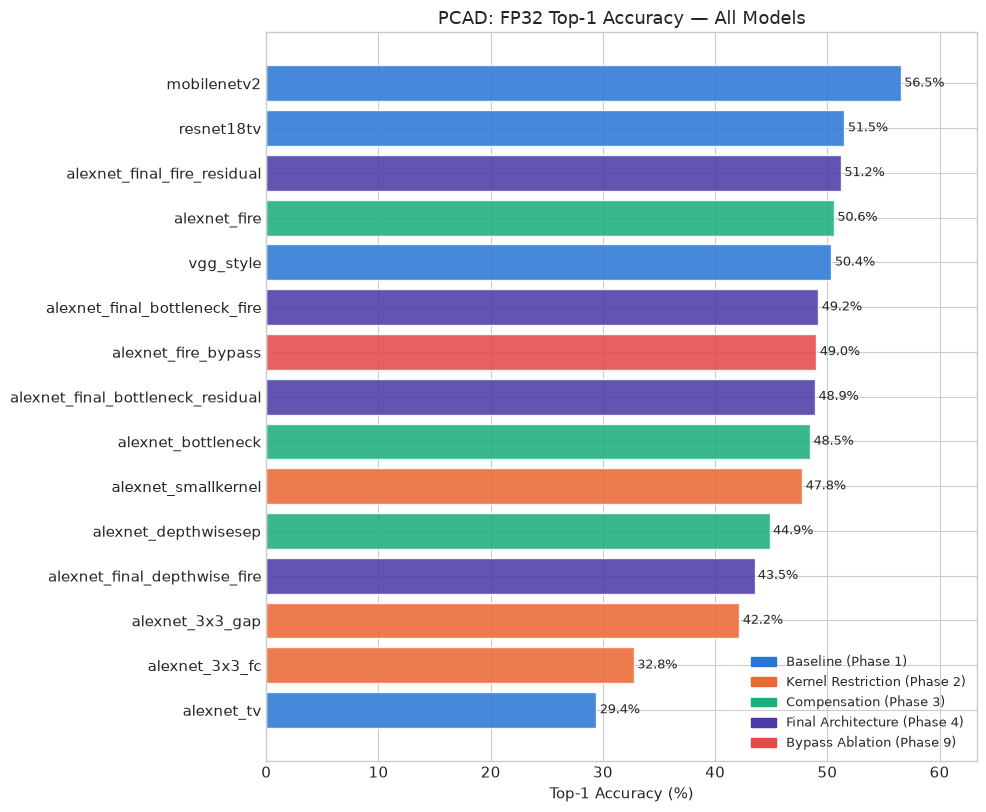

In [20]:
if not df_data.empty and "fp32_top1" in df_data.columns:
    df_plot = df_data.sort_values("fp32_top1", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, max(5, len(df_plot) * 0.55)))
    bar_colors = category_colors_for(df_plot["model_name"])
    bars = ax.barh(df_plot["model_name"], df_plot["fp32_top1"],
                    color=bar_colors, edgecolor="white", alpha=0.87)

    for bar, val in zip(bars, df_plot["fp32_top1"]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=9)

    ax.set_xlabel("Top-1 Accuracy (%)")
    ax.set_title("PCAD: FP32 Top-1 Accuracy — All Models")
    ax.set_xlim(0, df_plot["fp32_top1"].max() * 1.12)
    ax.legend(handles=category_legend_handles(df_plot["model_name"]), loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pcad_fp32_accuracy_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("[skip] No FP32 Top-1 data available")

### 2. FP32 vs INT8 Quantization Drop

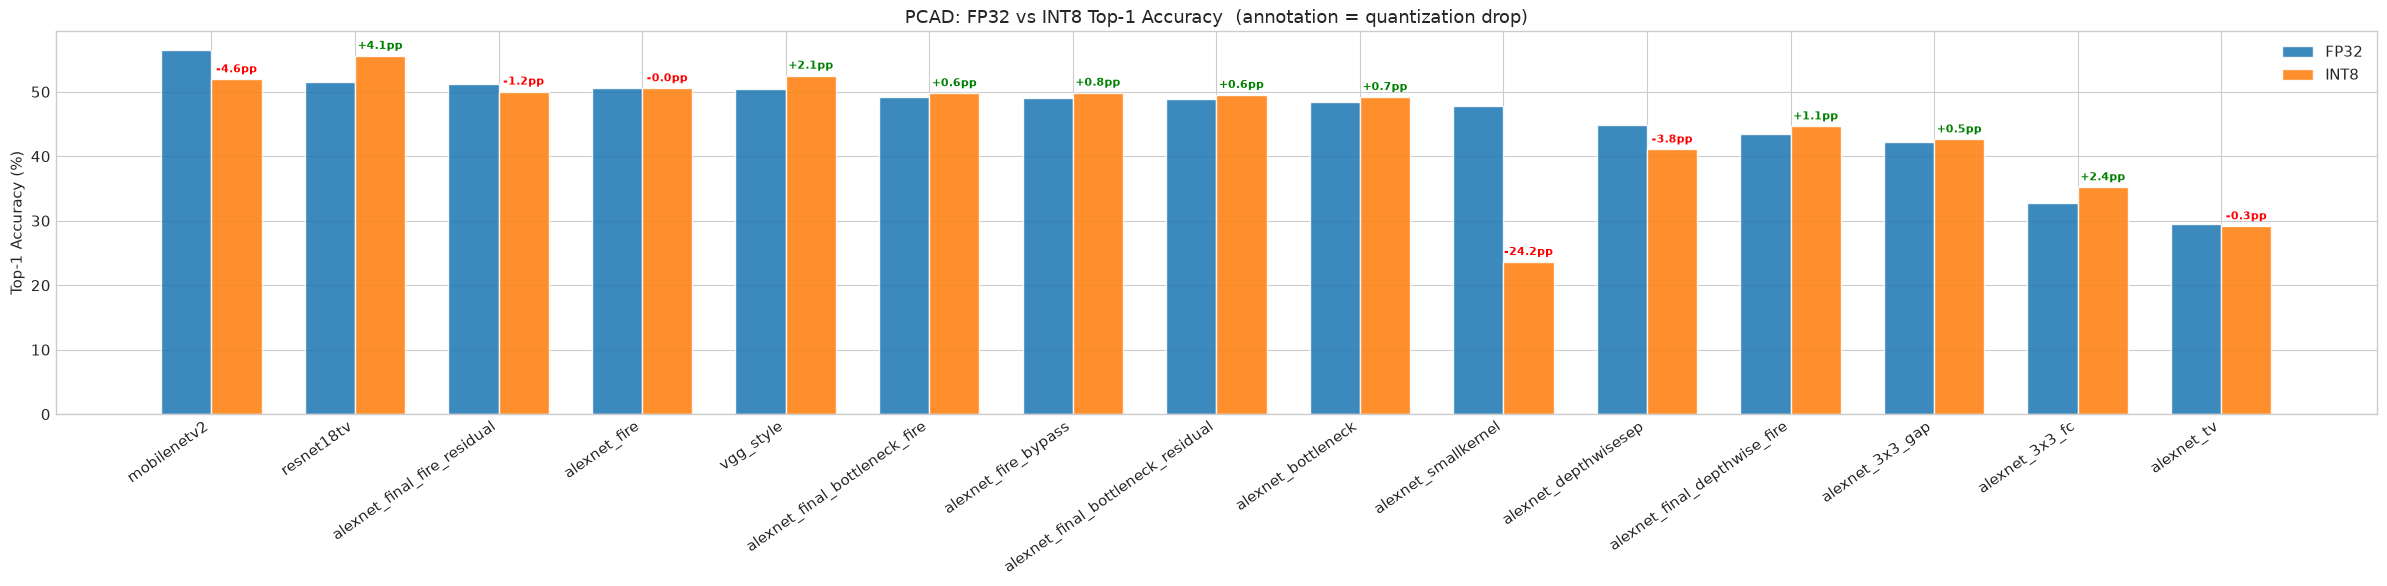

In [21]:
if not df_data.empty and all(c in df_data.columns for c in ["fp32_top1", "int8_top1"]):
    df_qat = df_data[df_data["int8_top1"].notna()].copy()
    
    if not df_qat.empty:
        df_qat["drop"] = df_qat["fp32_top1"] - df_qat["int8_top1"]
        df_qat = df_qat.sort_values("fp32_top1", ascending=False).reset_index(drop=True)

        x = np.arange(len(df_qat))
        w = 0.35

        fig, ax = plt.subplots(figsize=(max(10, len(df_qat) * 1.6), 6))
        ax.bar(x - w / 2, df_qat["fp32_top1"], w, label="FP32", 
               color=COLORS['fp32'], alpha=0.87, edgecolor="white")
        ax.bar(x + w / 2, df_qat["int8_top1"], w, label="INT8", 
               color=COLORS['int8'], alpha=0.87, edgecolor="white")

        for i, row in df_qat.iterrows():
            color = "red" if row["drop"] > 0 else "green"
            sign  = "-" if row["drop"] > 0 else "+"
            ax.annotate(
                f"{sign}{abs(row['drop']):.1f}pp",
                xy=(x[i] + w / 2, row["int8_top1"]),
                xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=8, color=color, fontweight="bold",
            )

        ax.set_xticks(x)
        ax.set_xticklabels(df_qat["model_name"], rotation=35, ha="right")
        ax.set_ylabel("Top-1 Accuracy (%)")
        ax.set_title("PCAD: FP32 vs INT8 Top-1 Accuracy  (annotation = quantization drop)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "pcad_fp32_vs_int8_bar.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("[skip] No INT8 data available")
else:
    print("[skip] Missing FP32/INT8 columns")

### 2b. Quantization Drop by Model Family

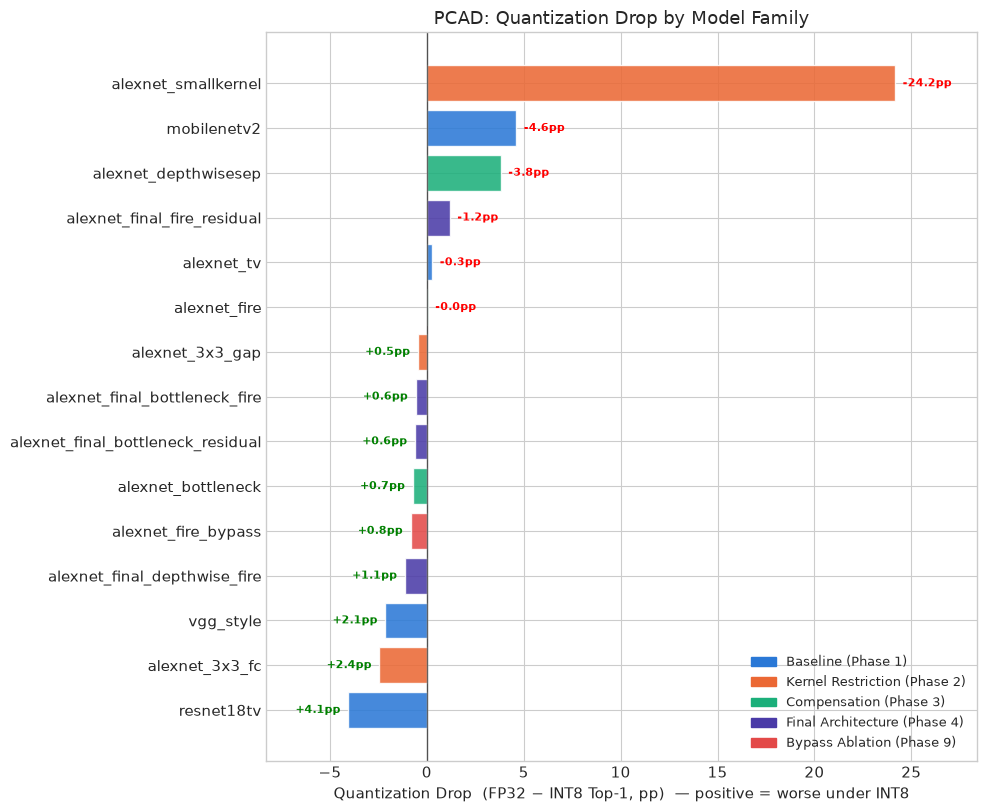

In [22]:
if not df_data.empty and "quantization_drop_top1" in df_data.columns and df_data["quantization_drop_top1"].notna().any():
    df_drop = df_data[df_data["quantization_drop_top1"].notna()].copy()
    df_drop = df_drop.sort_values("quantization_drop_top1", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, max(5, len(df_drop) * 0.55)))
    bars = ax.barh(df_drop["model_name"], df_drop["quantization_drop_top1"],
                    color=category_colors_for(df_drop["model_name"]), edgecolor="white", alpha=0.87)

    for bar, val in zip(bars, df_drop["quantization_drop_top1"]):
        color = "red" if val > 0 else "green"
        sign = "-" if val > 0 else "+"
        ax.text(val + (0.4 if val >= 0 else -0.4), bar.get_y() + bar.get_height() / 2,
                f"{sign}{abs(val):.1f}pp", va="center",
                ha="left" if val >= 0 else "right", fontsize=8, color=color, fontweight="bold")

    vmin, vmax = df_drop["quantization_drop_top1"].min(), df_drop["quantization_drop_top1"].max()
    pad = max(vmax - vmin, 1) * 0.15
    ax.set_xlim(vmin - pad, vmax + pad)

    ax.axvline(0, color="black", lw=1, alpha=0.6)
    ax.set_xlabel("Quantization Drop  (FP32 − INT8 Top-1, pp)  — positive = worse under INT8")
    ax.set_title("PCAD: Quantization Drop by Model Family")
    ax.legend(handles=category_legend_handles(df_drop["model_name"]), loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pcad_quantization_drop_by_family.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("[skip] No quantization drop data available")

### 3. Accuracy vs Model Size

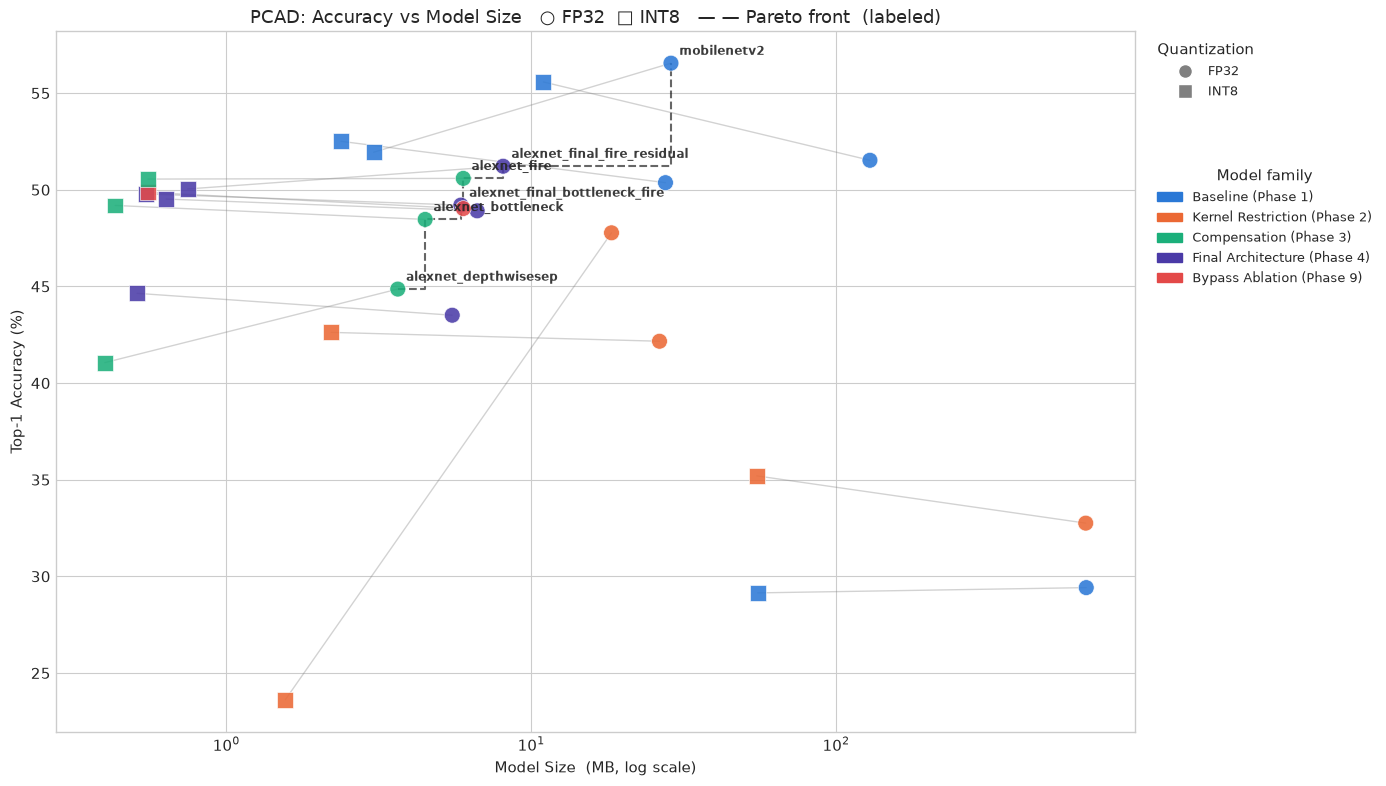

In [23]:
def pareto_front_mask(xs, ys):
    """Boolean mask: True if point is Pareto-optimal (minimize x, maximize y)."""
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    dominated = np.zeros(len(xs), dtype=bool)
    for i in range(len(xs)):
        for j in range(len(xs)):
            if i != j and xs[j] <= xs[i] and ys[j] >= ys[i] and (xs[j] < xs[i] or ys[j] > ys[i]):
                dominated[i] = True
                break
    return ~dominated


if not df_data.empty and all(c in df_data.columns for c in ["fp32_top1", "fp32_size_mb"]):
    df_fp32 = df_data[df_data["fp32_top1"].notna() & df_data["fp32_size_mb"].notna()].copy()
    df_int8 = df_data[df_data["int8_top1"].notna() & df_data["int8_size_mb"].notna()].copy()

    fig, ax = plt.subplots(figsize=(14, 8))

    # FP32 → INT8 connector lines
    for fp32_idx, fp32_row in df_fp32.iterrows():
        int8_match = df_int8[df_int8["model_name"] == fp32_row["model_name"]]
        if not int8_match.empty:
            int8_row = int8_match.iloc[0]
            ax.plot([fp32_row["fp32_size_mb"], int8_row["int8_size_mb"]],
                   [fp32_row["fp32_top1"], int8_row["int8_top1"]],
                   color="gray", lw=1, alpha=0.35, zorder=1)

    # FP32 scatter (circles), INT8 scatter (squares) — both colored by model family
    ax.scatter(df_fp32["fp32_size_mb"], df_fp32["fp32_top1"],
               c=category_colors_for(df_fp32["model_name"]), marker="o", s=130,
               zorder=3, edgecolors="white", lw=0.5, alpha=0.87)

    if not df_int8.empty:
        ax.scatter(df_int8["int8_size_mb"], df_int8["int8_top1"],
                   c=category_colors_for(df_int8["model_name"]), marker="s", s=130,
                   zorder=3, edgecolors="white", lw=0.5, alpha=0.87)

    # Pareto front (FP32) — and the only points we label, to keep the chart readable
    if len(df_fp32) >= 2:
        pf_mask = pareto_front_mask(df_fp32["fp32_size_mb"].values, df_fp32["fp32_top1"].values)
        pf = df_fp32[pf_mask].sort_values("fp32_size_mb")
        ax.step(pf["fp32_size_mb"], pf["fp32_top1"], where="post",
                color="black", lw=1.5, ls="--", alpha=0.6, zorder=2)
        for _, row in pf.iterrows():
            ax.annotate(row["model_name"], (row["fp32_size_mb"], row["fp32_top1"]),
                        xytext=(6, 6), textcoords="offset points", fontsize=8.5,
                        fontweight="bold", alpha=0.9)

    ax.set_xscale("log")
    ax.set_xlabel("Model Size  (MB, log scale)")
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title("PCAD: Accuracy vs Model Size   ○ FP32  □ INT8   — — Pareto front  (labeled)")

    marker_handles = [
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="gray",
                   markeredgecolor="white", markersize=10, label="FP32"),
        plt.Line2D([0], [0], marker="s", color="none", markerfacecolor="gray",
                   markeredgecolor="white", markersize=10, label="INT8"),
    ]
    marker_legend = ax.legend(handles=marker_handles, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, title="Quantization")
    ax.add_artist(marker_legend)
    ax.legend(handles=category_legend_handles(df_fp32["model_name"]), loc="upper left", bbox_to_anchor=(1.01, 0.82), fontsize=9, title="Model family")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pcad_accuracy_vs_size.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("[skip] Missing accuracy or size columns")

### 4. Accuracy vs Compute (MACs)

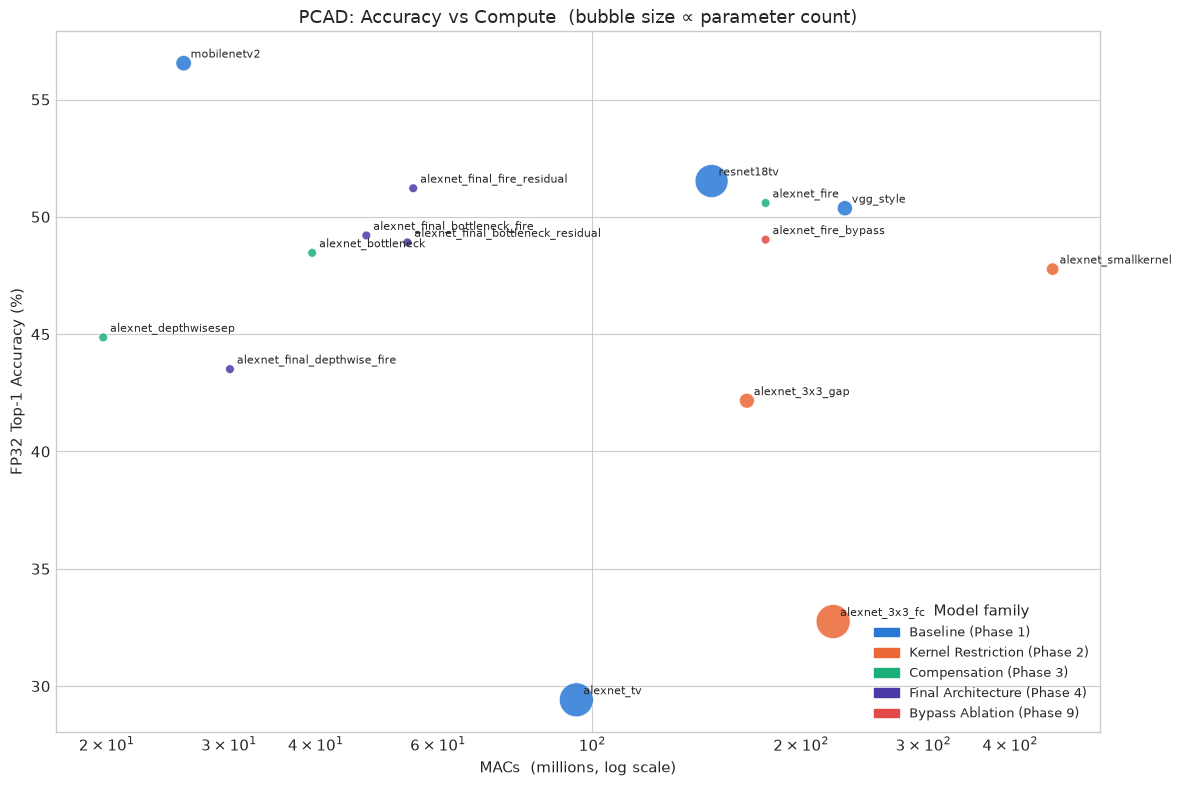

In [24]:
if not df_data.empty and all(c in df_data.columns for c in ["macs", "fp32_top1"]) and df_data["macs"].notna().any():
    df_macs = df_data[df_data["macs"].notna() & df_data["fp32_top1"].notna()].copy()
    df_macs["macs_M"] = df_macs["macs"] / 1e6

    fig, ax = plt.subplots(figsize=(12, 8))
    sizes = (df_macs["params_m"].fillna(1) * 50).clip(40, 600)

    ax.scatter(df_macs["macs_M"], df_macs["fp32_top1"],
               c=category_colors_for(df_macs["model_name"]), s=sizes,
               alpha=0.85, edgecolors="white", lw=0.5)

    for _, row in df_macs.iterrows():
        ax.annotate(row["model_name"], (row["macs_M"], row["fp32_top1"]),
                    xytext=(5, 4), textcoords="offset points", fontsize=8)

    ax.set_xscale("log")
    ax.set_xlabel("MACs  (millions, log scale)")
    ax.set_ylabel("FP32 Top-1 Accuracy (%)")
    ax.set_title("PCAD: Accuracy vs Compute  (bubble size ∝ parameter count)")
    ax.legend(handles=category_legend_handles(df_macs["model_name"]), loc="lower right", fontsize=9, title="Model family")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pcad_accuracy_vs_macs.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("[skip] No MACs/accuracy data")

### 5. Model Efficiency — Accuracy per MB

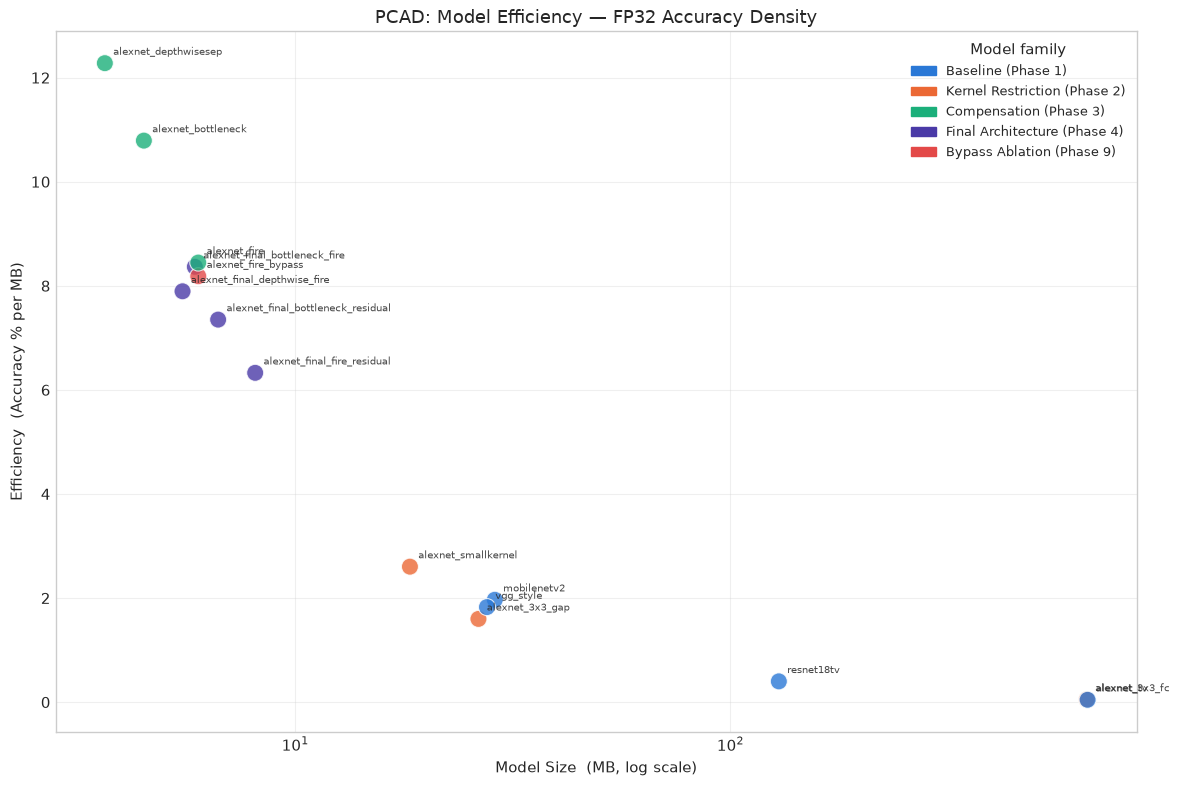

In [25]:
if not df_data.empty and all(c in df_data.columns for c in ["fp32_top1", "fp32_size_mb"]):
    df_eff = df_data[df_data["fp32_top1"].notna() & df_data["fp32_size_mb"].notna()].copy()
    df_eff["accuracy_per_mb"] = df_eff["fp32_top1"] / df_eff["fp32_size_mb"]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(df_eff["fp32_size_mb"], df_eff["accuracy_per_mb"],
               c=category_colors_for(df_eff["model_name"]), marker="o", s=150,
               alpha=0.8, edgecolors="white", lw=0.8, zorder=3)

    for _, row in df_eff.iterrows():
        ax.annotate(row["model_name"], (row["fp32_size_mb"], row["accuracy_per_mb"]),
                    xytext=(6, 6), textcoords="offset points", fontsize=7.5, alpha=0.85)

    ax.set_xscale("log")
    ax.set_xlabel("Model Size  (MB, log scale)")
    ax.set_ylabel("Efficiency  (Accuracy % per MB)")
    ax.set_title("PCAD: Model Efficiency — FP32 Accuracy Density")
    ax.grid(True, alpha=0.3)
    ax.legend(handles=category_legend_handles(df_eff["model_name"]), loc="upper right", fontsize=9, title="Model family")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pcad_efficiency_accuracy_per_mb.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("[skip] No efficiency data")

### 6. Inference Latency — FP32 vs INT8

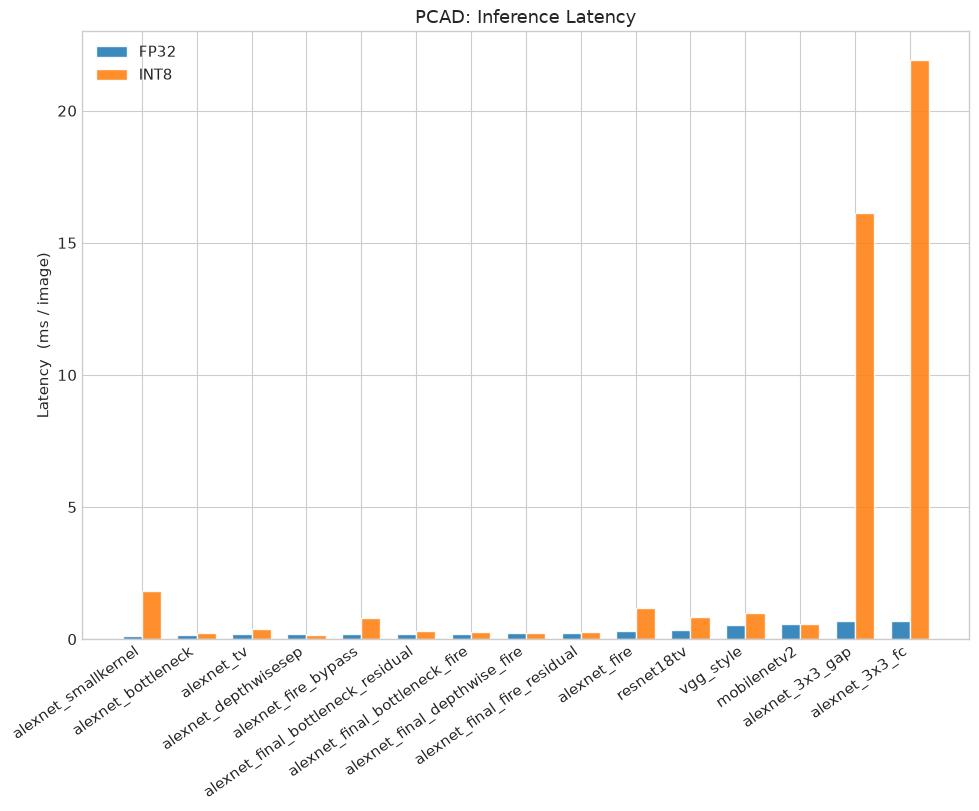

In [26]:
if not df_data.empty and all(c in df_data.columns for c in ["fp32_latency_ms_per_image"]):
    df_lat = df_data[df_data["fp32_latency_ms_per_image"].notna()].copy()
    df_lat = df_lat.sort_values("fp32_latency_ms_per_image")

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_lat) * 0.55)))
    
    x = np.arange(len(df_lat))
    w = 0.35
    
    # FP32 latency
    bars1 = ax.bar(x - w/2, df_lat["fp32_latency_ms_per_image"], w, 
                    label="FP32", color=COLORS['fp32'], alpha=0.87, edgecolor="white")
    
    # INT8 latency (if available)
    if "int8_latency_ms_per_image" in df_lat.columns and df_lat["int8_latency_ms_per_image"].notna().any():
        bars2 = ax.bar(x + w/2, df_lat["int8_latency_ms_per_image"], w, 
                        label="INT8", color=COLORS['int8'], alpha=0.87, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(df_lat["model_name"], rotation=35, ha="right")
    ax.set_ylabel("Latency  (ms / image)")
    ax.set_title("PCAD: Inference Latency")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pcad_latency_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("[skip] No latency data")

### 7. GPU Power & Temperature During Training

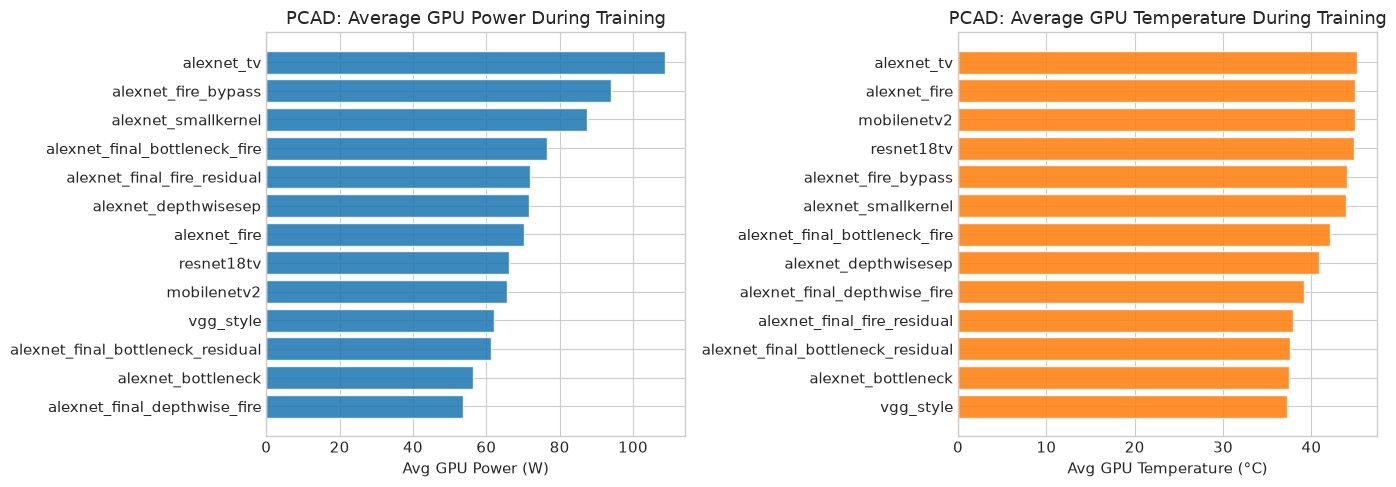

In [27]:
if not df_data.empty and all(c in df_data.columns for c in ["avg_gpu_power_w", "avg_gpu_temp_c"]):
    df_power = df_data[df_data["avg_gpu_power_w"].notna() & df_data["avg_gpu_temp_c"].notna()].copy()
    
    if not df_power.empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Power
        df_power_sorted = df_power.sort_values("avg_gpu_power_w")
        ax1.barh(df_power_sorted["model_name"], df_power_sorted["avg_gpu_power_w"],
                color=COLORS['fp32'], alpha=0.87, edgecolor="white")
        ax1.set_xlabel("Avg GPU Power (W)")
        ax1.set_title("PCAD: Average GPU Power During Training")
        
        # Temperature
        df_temp_sorted = df_power.sort_values("avg_gpu_temp_c")
        ax2.barh(df_temp_sorted["model_name"], df_temp_sorted["avg_gpu_temp_c"],
                color=COLORS['int8'], alpha=0.87, edgecolor="white")
        ax2.set_xlabel("Avg GPU Temperature (°C)")
        ax2.set_title("PCAD: Average GPU Temperature During Training")
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "pcad_power_temperature.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("[skip] No power/temperature data")
else:
    print("[skip] Missing power/temperature columns")

### 8. Training Time & Throughput

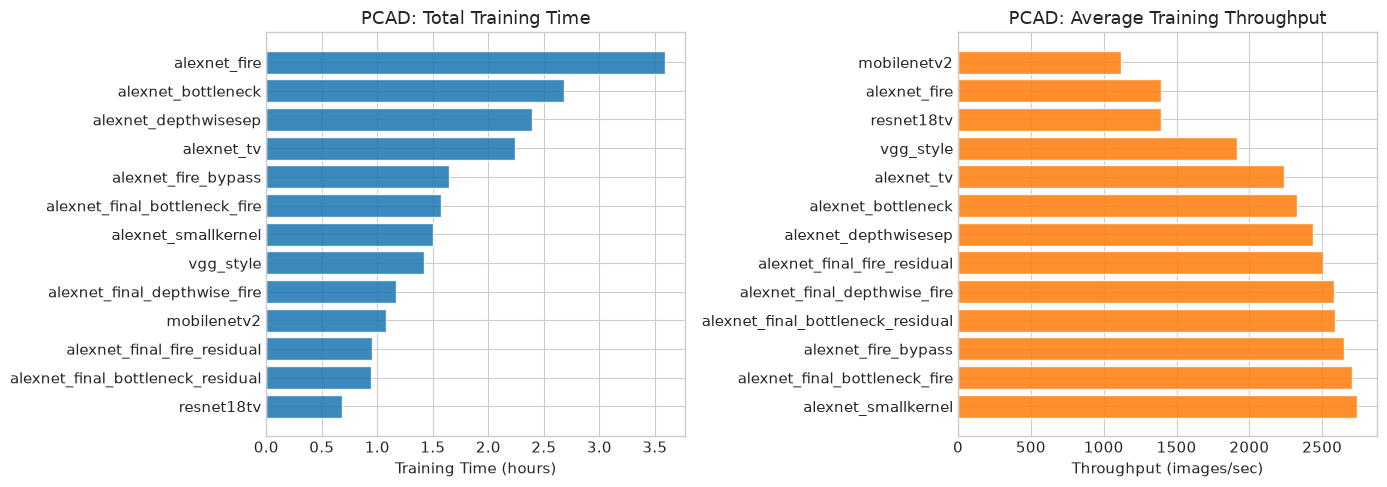

In [28]:
if not df_data.empty and all(c in df_data.columns for c in ["total_training_time_s", "avg_images_per_sec"]):
    df_time = df_data[df_data["total_training_time_s"].notna() & df_data["avg_images_per_sec"].notna()].copy()
    
    if not df_time.empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Training time in hours
        df_time["training_hours"] = df_time["total_training_time_s"] / 3600
        df_time_sorted = df_time.sort_values("training_hours")
        ax1.barh(df_time_sorted["model_name"], df_time_sorted["training_hours"],
                color=COLORS['fp32'], alpha=0.87, edgecolor="white")
        ax1.set_xlabel("Training Time (hours)")
        ax1.set_title("PCAD: Total Training Time")
        
        # Throughput
        df_throughput_sorted = df_time.sort_values("avg_images_per_sec", ascending=False)
        ax2.barh(df_throughput_sorted["model_name"], df_throughput_sorted["avg_images_per_sec"],
                color=COLORS['int8'], alpha=0.87, edgecolor="white")
        ax2.set_xlabel("Throughput (images/sec)")
        ax2.set_title("PCAD: Average Training Throughput")
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "pcad_training_time_throughput.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("[skip] No training time data")
else:
    print("[skip] Missing training time columns")

## Export Results Summary

In [29]:
if not df_data.empty:
    # Export full comparison table
    export_path = PCAD_DIR / "results_aggregate" / "results_cross_phase_summary.csv"
    df_data.to_csv(export_path, index=False)
    print(f"✓ Exported {len(df_data)} rows → {export_path}")
    
    # Summary statistics
    print(f"\n=== PCAD Results Summary ===")
    print(f"Total models: {len(df_data)}")
    print(f"\nFP32 Top-1 Accuracy:")
    print(f"  Mean: {df_data['fp32_top1'].mean():.2f}%")
    print(f"  Min:  {df_data['fp32_top1'].min():.2f}%")
    print(f"  Max:  {df_data['fp32_top1'].max():.2f}%")
    
    if "quantization_drop_top1" in df_data.columns and df_data["quantization_drop_top1"].notna().any():
        print(f"\nQuantization Drop (FP32 → INT8):")
        print(f"  Mean: {df_data['quantization_drop_top1'].mean():.2f}pp")
        print(f"  Max:  {df_data['quantization_drop_top1'].max():.2f}pp")
    
    if all(c in df_data.columns for c in ["fp32_size_mb", "int8_size_mb"]):
        print(f"\nModel Compression (FP32 → INT8):")
        print(f"  Avg size reduction: {(df_data['fp32_size_mb'].mean() / df_data['int8_size_mb'].mean()):.1f}x (where available)")
else:
    print("[skip] No comparison data to export")

✓ Exported 15 rows → /home/users/rsdsouza/dnn_study/outputs/pcad/results_aggregate/results_cross_phase_summary.csv

=== PCAD Results Summary ===
Total models: 15

FP32 Top-1 Accuracy:
  Mean: 46.42%
  Min:  29.42%
  Max:  56.55%

Quantization Drop (FP32 → INT8):
  Mean: 1.41pp
  Max:  24.16pp

Model Compression (FP32 → INT8):
  Avg size reduction: 11.8x (where available)
